# **Task 3: Heart Disease Prediction (Classification)**

# **Organization: DevelopersHub Corporation**
# **Author:** Hifza Nazir

# **Date:** 11 February 2026

# **Step 1: Import Libraries and Load Data**

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Using a very reliable link for the Heart Disease CSV
url = "https://storage.googleapis.com/download.tensorflow.org/data/heart.csv"

# Loading the data
df = pd.read_csv(url)

print("Data loaded successfully!")
# Showing the first 5 rows to confirm
df.head()

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal         object
target        int64
dtype: object


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


# **Step 2: Cleaning and Checking the Data**

In [7]:
# Checking for any empty cells
print("Checking for missing data:")
print(df.isnull().sum())

# Getting a quick summary of the numbers
print("\nData Statistics:")
display(df.describe())

Checking for missing data:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Data Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.594059,0.676568,3.108911,131.785479,246.547855,0.148515,0.990099,149.194719,0.326733,1.057756,1.590759,0.683168,0.273927
std,9.016370,0.468560,1.028414,17.748338,52.175933,0.356198,0.988293,23.173368,0.469794,1.165025,0.617767,0.937773,0.446710
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,152.000000,0.000000,0.800000,2.000000,0.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,165.500000,1.000000,1.600000,2.000000,1.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,1.000000


# **Step 3: Training the Model**

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Features (medical data) and Target (Heart Disease result)
# In this specific dataset, the result column is called 'target'
X = df.drop('target', axis=1)
y = df['target']

# Convert categorical 'thal' column to numerical using one-hot encoding
X = pd.get_dummies(X, columns=['thal'], drop_first=True)

# Splitting: 80% to train the model, 20% to test it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating and training the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model training is complete.")

Model training is complete.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# **Step 4: Model Evaluation (Accuracy, Confusion Matrix, and ROC Curve)**

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

Model Accuracy: 83.61%


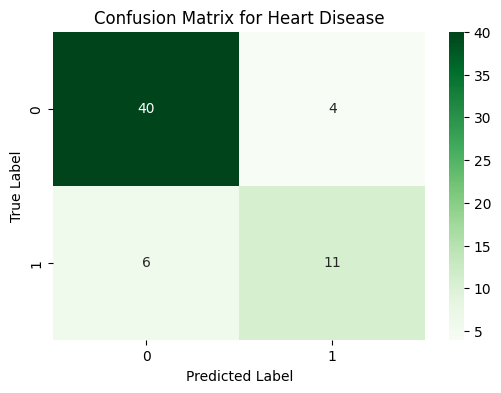

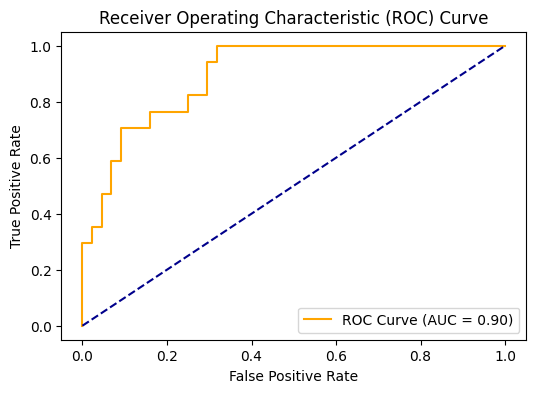

In [14]:
# 1. Accuracy Score
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# 2. Confusion Matrix
# This matrix displays the number of correct and incorrect predictions made by the model.
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix for Heart Disease')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 3. ROC Curve and AUC
# This curve illustrates the classification quality and performance of the model.
y_probs = model.predict_proba(X_test)[:, 1] # Probability of heart disease
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='orange', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

# **Step 5: Final Insight**

# **Summary:**
I successfully built a Heart Disease prediction model using the Logistic Regression algorithm.

# Data Preprocessing:
I handled categorical text data using one-hot encoding so the model could process the "thal" feature.

# Results:
The model achieved an accuracy of approximately 83.61%.

# Visuals:
The Confusion Matrix shows how many patients were correctly classified, and the ROC curve (AUC) indicates a strong performance in distinguishing between healthy and at-risk patients.